## Reducers 

These are used to resolve the conflict in case of share state 

#### Fan out and fan in

Let's build a simple linear graph that over-writes the state at each step.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [3]:
from typing import TypedDict, List, Dict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [6]:
class NodeState(TypedDict):
    msg : List[str]

def node_a(state: NodeState):
    print(f'Adding A to {state['msg']}')
    return {'msg': ['A']}

def node_b(state: NodeState):
    print(f'Adding B to {state['msg']}')
    return {'msg': ['B']}

def node_c(state: NodeState):
    print(f'Adding C to {state['msg']}')
    return {'msg': ['C']}

def node_d(state: NodeState):
    print(f'Adding D to {state['msg']}')
    return {'msg': ['D']}

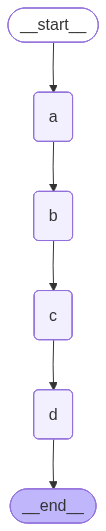

In [7]:
builder = StateGraph(NodeState)
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)
builder.add_node('d', node_d)

# Logic Edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('b', 'c')
builder.add_edge('c', 'd')
builder.add_edge('d', END)

lin_flow = builder.compile()
display(Image(lin_flow.get_graph().draw_mermaid_png()))

In [8]:
lin_flow.invoke({'msg': []})

Adding A to []
Adding B to ['A']
Adding C to ['B']
Adding D to ['C']


{'msg': ['D']}

All the messages got overwritten on the linear Flow


Now Adding B and C in parallel ->
`__start__ -> A -> B || C -> D -> __end__`

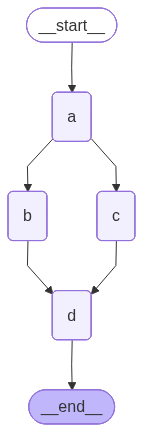

In [9]:
builder = StateGraph(NodeState)
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)
builder.add_node('d', node_d)

# Logic Edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('c', 'd')
builder.add_edge('b', 'd')
builder.add_edge('d', END)

pl_flow = builder.compile()
display(Image(pl_flow.get_graph().draw_mermaid_png()))

In [11]:
from langgraph.errors import InvalidUpdateError
try:
    pl_flow.invoke({"msg": []})
except InvalidUpdateError as e:
    print(f"An error occurred: {e}")

# Error as getting multiple vauels at D.

Adding A to []
Adding B to ['A']
Adding C to ['A']
An error occurred: At key 'msg': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


### Reducers

- Resolves the conflict for the values at at node

In [13]:
from operator import add
from typing import Annotated

In [14]:
class NodeState(TypedDict):
    msg: Annotated[List[str], add] # Add is the reducer


In [15]:
def node_a(state: NodeState):
    print(f'Adding A to {state['msg']}')
    return {'msg': ['A']}

def node_b(state: NodeState):
    print(f'Adding B to {state['msg']}')
    return {'msg': ['B']}

def node_c(state: NodeState):
    print(f'Adding C to {state['msg']}')
    return {'msg': ['C']}

def node_d(state: NodeState):
    print(f'Adding D to {state['msg']}')
    return {'msg': ['D']}

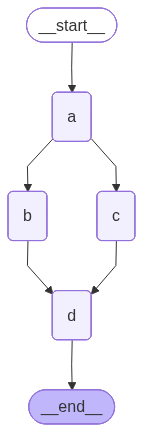

In [16]:
builder = StateGraph(NodeState)
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)
builder.add_node('d', node_d)

# Logic Edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('c', 'd')
builder.add_edge('b', 'd')
builder.add_edge('d', END)

pl_flow = builder.compile()
display(Image(pl_flow.get_graph().draw_mermaid_png()))

In [17]:
pl_flow.invoke({"msg":[]})

Adding A to []
Adding B to ['A']
Adding C to ['A']
Adding D to ['A', 'B', 'C']


{'msg': ['A', 'B', 'C', 'D']}

#### Multiple steps in parallel path

In [18]:
class State(TypedDict):
    msg: Annotated[List[str], add]

def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['msg']}")
    return {"msg": ["A"]}

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['msg']}")
    return {"msg": ["B"]}

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['msg']}")
    return {"msg": ["C"]}

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['msg']}")
    return {"msg": ["BB"]}

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['msg']}")
    return {"msg": ["CC"]}
    
def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['msg']}")
    return {"msg": ["D"]}

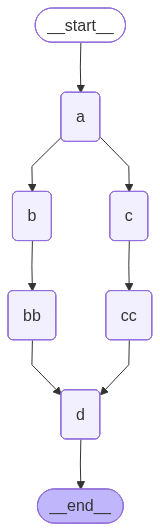

In [19]:
builder = StateGraph(State)

builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)
builder.add_node('d', node_d)
builder.add_node('bb', node_bb)
builder.add_node('cc', node_cc)

# Adding edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('b', 'bb')
builder.add_edge('c', 'cc')
builder.add_edge('bb', 'd')
builder.add_edge('cc', 'd')
builder.add_edge('d', END)

pl_flow = builder.compile()
display(Image(pl_flow.get_graph().draw_mermaid_png()))

In [20]:
initial_state = State(msg = [])
pl_flow.invoke(initial_state)

Adding 'A' to []
Adding 'B' to ['A']
Adding 'C' to ['A']
Adding 'BB' to ['A', 'B', 'C']
Adding 'CC' to ['A', 'B', 'C']
Adding 'D' to ['A', 'B', 'C', 'BB', 'CC']


{'msg': ['A', 'B', 'C', 'BB', 'CC', 'D']}

#### Multiple step only at single side

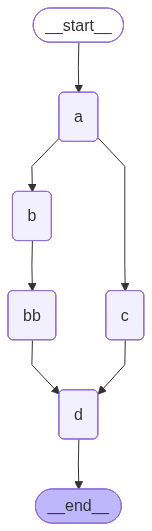

In [31]:
builder = StateGraph(State)

builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)
builder.add_node('d', node_d)
builder.add_node('bb', node_bb)

# Adding edges
builder.add_edge(START, 'a')
builder.add_edge('a', 'b')
builder.add_edge('a', 'c')
builder.add_edge('b', 'bb')
builder.add_edge(['bb', 'c'], 'd')
builder.add_edge('d', END)

pl_flow1 = builder.compile()
display(Image(pl_flow1.get_graph().draw_mermaid_png()))

In [32]:
pl_flow1.invoke(initial_state)

Adding 'A' to []
Adding 'B' to ['A']
Adding 'C' to ['A']
Adding 'BB' to ['A', 'B', 'C']
Adding 'D' to ['A', 'B', 'BB', 'C']


{'msg': ['A', 'B', 'BB', 'C', 'D']}

In [27]:
# Question - Why this is being ran twice

In [28]:
def custom_sorting_reducer(left, right):
    '''Combines and sort the values in a list'''
    if not isinstance(left, list):
        left = [left]
    
    if not isinstance(right, list):
        right = [right]
    return sorted(left + right, reverse=False)

class State(TypedDict):
    msg: Annotated[List[str], custom_sorting_reducer]

def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['msg']}")
    return {"msg": ["A"]}

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['msg']}")
    return {"msg": ["B"]}

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['msg']}")
    return {"msg": ["C"]}

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['msg']}")
    return {"msg": ["BB"]}

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['msg']}")
    return {"msg": ["CC"]}
    
def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['msg']}")
    return {"msg": ["D"]} 

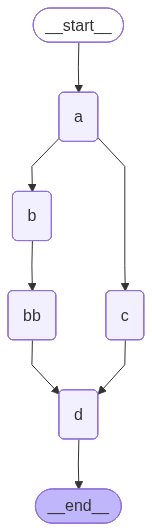

In [29]:
graph2 = StateGraph(State)

# Add nodes
graph2.add_node("a", node_a)
graph2.add_node("b", node_b)
graph2.add_node("c", node_c)
graph2.add_node("bb", node_bb)
graph2.add_node("d", node_d)

# Add edges
graph2.add_edge(START,"a")
graph2.add_edge("a", "b")
graph2.add_edge("a", "c")
graph2.add_edge("b", "bb")
graph2.add_edge(["bb", "c"], "d")
graph2.add_edge("d",END)

# Compile and display
workflow2 = graph2.compile()
display(Image(workflow2.get_graph().draw_mermaid_png()))

In [30]:
workflow2.invoke(initial_state)

Adding 'A' to []
Adding 'B' to ['A']
Adding 'C' to ['A']
Adding 'BB' to ['A', 'B', 'C']
Adding 'D' to ['A', 'B', 'BB', 'C']


{'msg': ['A', 'B', 'BB', 'C', 'D']}